# Stage 1 — Data Ingestion

**What this notebook covers:**

| Step | Task |
|---|---|
| 1 | Install & import required libraries |
| 2 | Load raw data from Hugging Face Hub (`mstz/titanic`) |
| 3 | Understand dataset structure (columns, types, shape) |
| 4 | Exploratory Data Analysis (EDA) |
| 5 | Detect data quality issues (nulls, outliers, imbalance) |
| 6 | Basic data cleaning |
| 7 | Data validation rules |
| 8 | Export cleaned data to disk (CSV + Parquet) |

**Dataset**: [mstz/titanic](https://huggingface.co/datasets/mstz/titanic) — 891 rows, binary classification (survived: 0/1).  
This is intentionally similar to the credit approval problem in your other notebooks: a binary decision based on tabular features.

## Step 1 — Install Libraries

- `pandas` — data manipulation
- `matplotlib` + `seaborn` — visualisation (seaborn also provides the dataset)
- `missingno` — visualise missing data patterns
- `pyarrow` — needed to save Parquet files


In [ ]:
!pip install pandas matplotlib seaborn missingno pyarrow --quiet


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import warnings
import os

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
print('All libraries imported successfully.')


All libraries imported successfully.


## Step 2 — Load Data

We use `seaborn.load_dataset('titanic')` to load the dataset.  
Seaborn ships with a curated collection of example datasets stored as standard CSV files — no legacy scripts involved.  
This produces the same Titanic data (891 rows, binary `survived` target) and gives us a clean `pandas` DataFrame directly.

> **Why not HuggingFace here?**  
> The `mstz/titanic` dataset on HuggingFace still uses a legacy loading script (`titanic.py`), which newer versions of the `datasets` library block entirely. Seaborn's copy is equivalent and has zero compatibility issues.


In [10]:
# Load Titanic dataset via seaborn's built-in loader
# seaborn downloads it from its own GitHub data repo — no legacy scripts involved
df_raw = sns.load_dataset('titanic')

print('Dataset structure:')
print(f'Shape: {df_raw.shape}')
print(f'Columns: {list(df_raw.columns)}')
print(f'\nLoaded {len(df_raw)} rows and {len(df_raw.columns)} columns.')


Dataset structure:
Shape: (891, 15)
Columns: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']

Loaded 891 rows and 15 columns.


**Note:** If you are offline or `seaborn`'s dataset server is unreachable, here is the local fallback:

```python
# Fallback: load from a local CSV (hand-downloaded Titanic CSV)
# df_raw = pd.read_csv("path/to/your/titanic.csv")
```

This is exactly what the credit approval notebooks do — they load from a local CSV.  
In production, this CSV would come from a database query, an S3 bucket, or a data pipeline.


## Step 3 — Understand the Dataset Structure

Before doing anything else, you must answer these questions:
1. What columns exist and what do they mean?
2. What are the data types?
3. How many rows and columns?
4. What is the target variable (what we want to predict)?

In [11]:
# First look at the data
print('=== First 5 rows ===')
df_raw.head()

=== First 5 rows ===


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [12]:
print('=== Shape (rows, columns) ===')
print(df_raw.shape)

print('\n=== Column Names and Data Types ===')
print(df_raw.dtypes)

print('\n=== Memory Usage ===')
print(df_raw.memory_usage(deep=True))

=== Shape (rows, columns) ===
(891, 15)

=== Column Names and Data Types ===
survived          int64
pclass            int64
sex                 str
age             float64
sibsp             int64
parch             int64
fare            float64
embarked            str
class          category
who                 str
adult_male         bool
deck           category
embark_town         str
alive               str
alone              bool
dtype: object

=== Memory Usage ===
Index            132
survived        7128
pclass          7128
sex            11320
age             7128
sibsp           7128
parch           7128
fare            7128
embarked        8129
class           1039
who            10509
adult_male       891
deck            1254
embark_town    16606
alive           9252
alone            891
dtype: int64


In [13]:
# Column-by-column description (seaborn titanic schema)
# This is what every data scientist must do before ANY modelling attempt
column_guide = {
    'survived'    : 'TARGET: 1 = survived, 0 = did not survive',
    'pclass'      : 'Ticket class: 1=First, 2=Second, 3=Third (socioeconomic proxy)',
    'sex'         : 'Gender — protected attribute (like RACE in credit data)',
    'age'         : 'Age in years — continuous, has missing values (~20%)',
    'sibsp'       : 'Number of siblings/spouses aboard',
    'parch'       : 'Number of parents/children aboard',
    'fare'        : 'Passenger fare — continuous',
    'embarked'    : 'Port of embarkation: C=Cherbourg, Q=Queenstown, S=Southampton',
    'class'       : 'Ticket class as string (redundant with pclass)',
    'who'         : 'Derived: man / woman / child',
    'adult_male'  : 'Derived boolean: True if adult male',
    'deck'        : 'Deck letter from cabin number — very sparse (lots of NaN)',
    'embark_town' : 'Port of embarkation as full city name (redundant with embarked)',
    'alive'       : 'Derived: yes / no (redundant with survived)',
    'alone'       : 'Derived boolean: True if travelling alone',
}

print('Column Guide:')
for col, desc in column_guide.items():
    if col in df_raw.columns:
        print(f'  {col:15s}: {desc}')


Column Guide:
  survived       : TARGET: 1 = survived, 0 = did not survive
  pclass         : Ticket class: 1=First, 2=Second, 3=Third (socioeconomic proxy)
  sex            : Gender — protected attribute (like RACE in credit data)
  age            : Age in years — continuous, has missing values (~20%)
  sibsp          : Number of siblings/spouses aboard
  parch          : Number of parents/children aboard
  fare           : Passenger fare — continuous
  embarked       : Port of embarkation: C=Cherbourg, Q=Queenstown, S=Southampton
  class          : Ticket class as string (redundant with pclass)
  who            : Derived: man / woman / child
  adult_male     : Derived boolean: True if adult male
  deck           : Deck letter from cabin number — very sparse (lots of NaN)
  embark_town    : Port of embarkation as full city name (redundant with embarked)
  alive          : Derived: yes / no (redundant with survived)
  alone          : Derived boolean: True if travelling alone


## Step 4 — Exploratory Data Analysis (EDA)

EDA answers: **"What does this data actually look like?"**

Key questions:
- What does the target distribution look like? (class balance)
- What are the value ranges for numeric features?
- What are the category frequencies for categorical features?
- Are there any obvious patterns?

In [14]:
# Statistical summary of numeric columns
print('=== Descriptive Statistics (numeric columns) ===')
df_raw.describe().round(2)

=== Descriptive Statistics (numeric columns) ===


,survived,pclass,age,sibsp,parch,fare
count,891.00,891.00,714.00,891.00,891.00,891.00
mean,0.38,2.31,29.70,0.52,0.38,32.20
std,0.49,0.84,14.53,1.10,0.81,49.69
min,0.00,1.00,0.42,0.00,0.00,0.00
25%,0.00,2.00,20.12,0.00,0.00,7.91
50%,0.00,3.00,28.00,0.00,0.00,14.45
75%,1.00,3.00,38.00,1.00,0.00,31.00
max,1.00,3.00,80.00,8.00,6.00,512.33


In [15]:
# Statistical summary of categorical columns
print('=== Descriptive Statistics (categorical columns) ===')
df_raw.describe(include='object')

=== Descriptive Statistics (categorical columns) ===


,sex,embarked,who,embark_town,alive
count,891,889,891,889,891
unique,2,3,3,3,2
top,male,S,man,Southampton,no
freq,577,644,537,644,549


Target variable distribution:
          count  percentage
survived                   
0           549        61.6
1           342        38.4


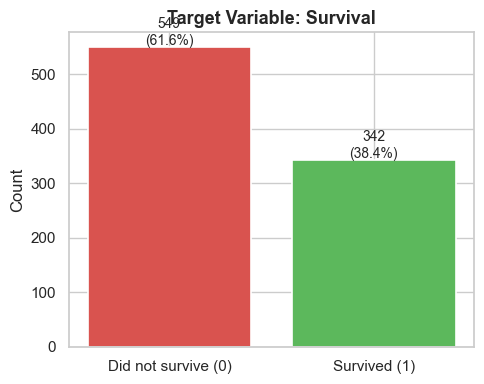

In [16]:
# ─── Target Variable Distribution ─────────────────────────────────────────────
# CRITICAL: This tells you if the dataset is balanced or imbalanced.
# If 95% of passengers did NOT survive, a model that always predicts 0
# would get 95% accuracy — which is MEANINGLESS.

target_col = 'survived'  # adjust if column name differs
value_counts = df_raw[target_col].value_counts()
value_pct = df_raw[target_col].value_counts(normalize=True) * 100

print('Target variable distribution:')
summary = pd.DataFrame({'count': value_counts, 'percentage': value_pct.round(1)})
print(summary)

# Visualise
fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(['Did not survive (0)', 'Survived (1)'], value_counts.values,
       color=['#d9534f', '#5cb85c'], edgecolor='white', linewidth=1.2)
ax.set_title('Target Variable: Survival', fontsize=13, fontweight='bold')
ax.set_ylabel('Count')
for i, v in enumerate(value_counts.values):
    ax.text(i, v + 5, f'{v}\n({value_pct.values[i]:.1f}%)', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

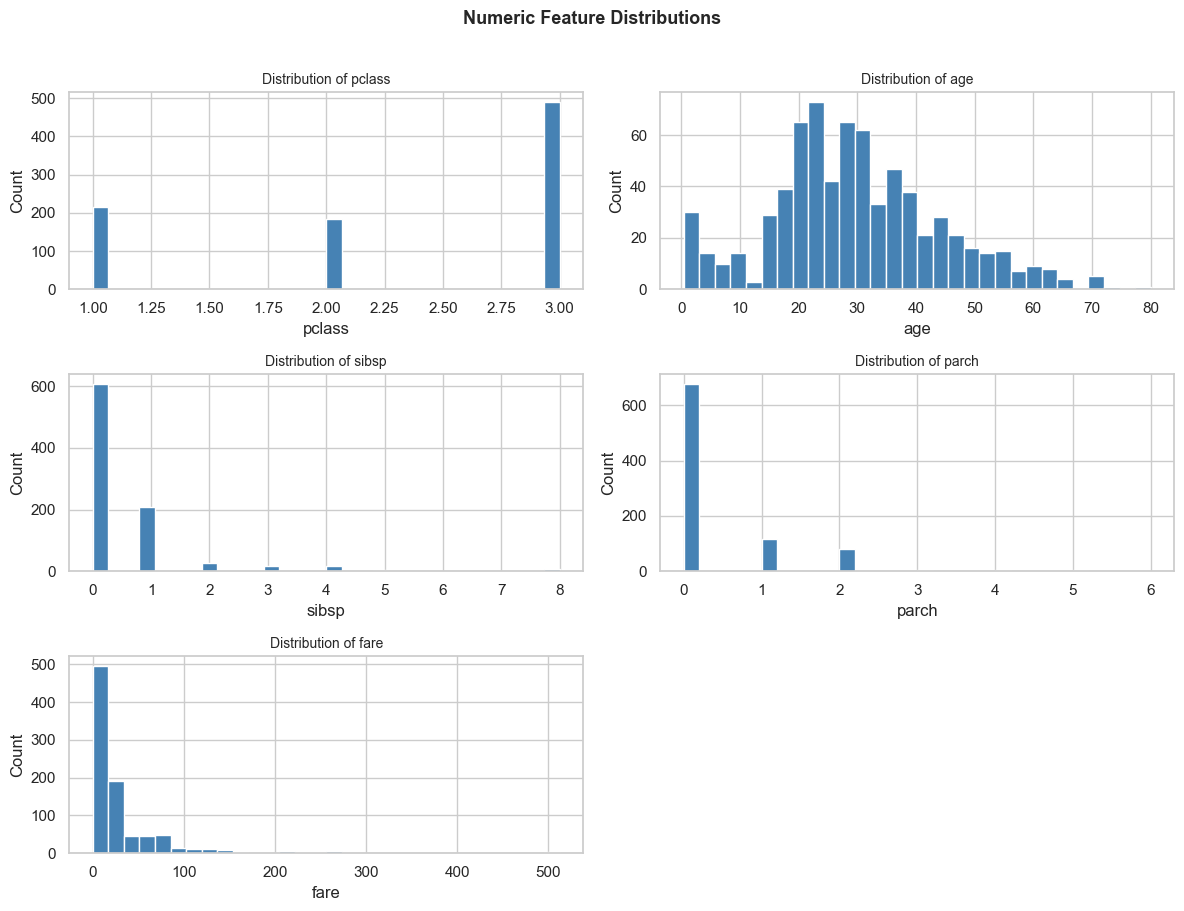

In [17]:
# ─── Numeric Feature Distributions ────────────────────────────────────────────
numeric_cols = df_raw.select_dtypes(include=[np.number]).columns.tolist()
# Remove ID and target from the plot
plot_cols = [c for c in numeric_cols if c.lower() not in ['passengerid', 'survived', 'passenger_id']]

n_cols = 2
n_rows = (len(plot_cols) + 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, n_rows * 3))
axes = axes.flatten()

for i, col in enumerate(plot_cols):
    axes[i].hist(df_raw[col].dropna(), bins=30, color='steelblue', edgecolor='white')
    axes[i].set_title(f'Distribution of {col}', fontsize=10)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')

# Hide unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Numeric Feature Distributions', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

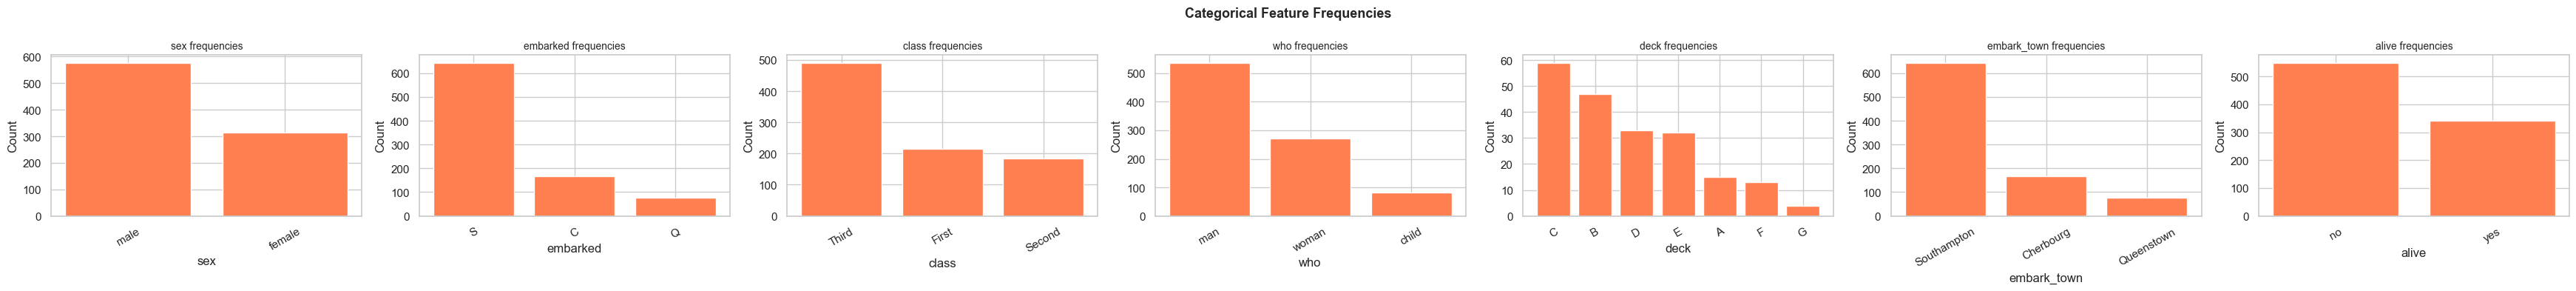

In [18]:
# ─── Categorical Feature Frequencies ──────────────────────────────────────────
cat_cols = df_raw.select_dtypes(include=['object', 'category']).columns.tolist()
# Skip high-cardinality columns like name, ticket, cabin
low_card_cats = [c for c in cat_cols if df_raw[c].nunique() <= 10]

if low_card_cats:
    fig, axes = plt.subplots(1, len(low_card_cats), figsize=(5 * len(low_card_cats), 4))
    if len(low_card_cats) == 1:
        axes = [axes]
    for i, col in enumerate(low_card_cats):
        counts = df_raw[col].value_counts()
        axes[i].bar(counts.index.astype(str), counts.values, color='coral', edgecolor='white')
        axes[i].set_title(f'{col} frequencies', fontsize=10)
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Count')
        axes[i].tick_params(axis='x', rotation=30)
    plt.suptitle('Categorical Feature Frequencies', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print('No low-cardinality categorical columns found to plot.')

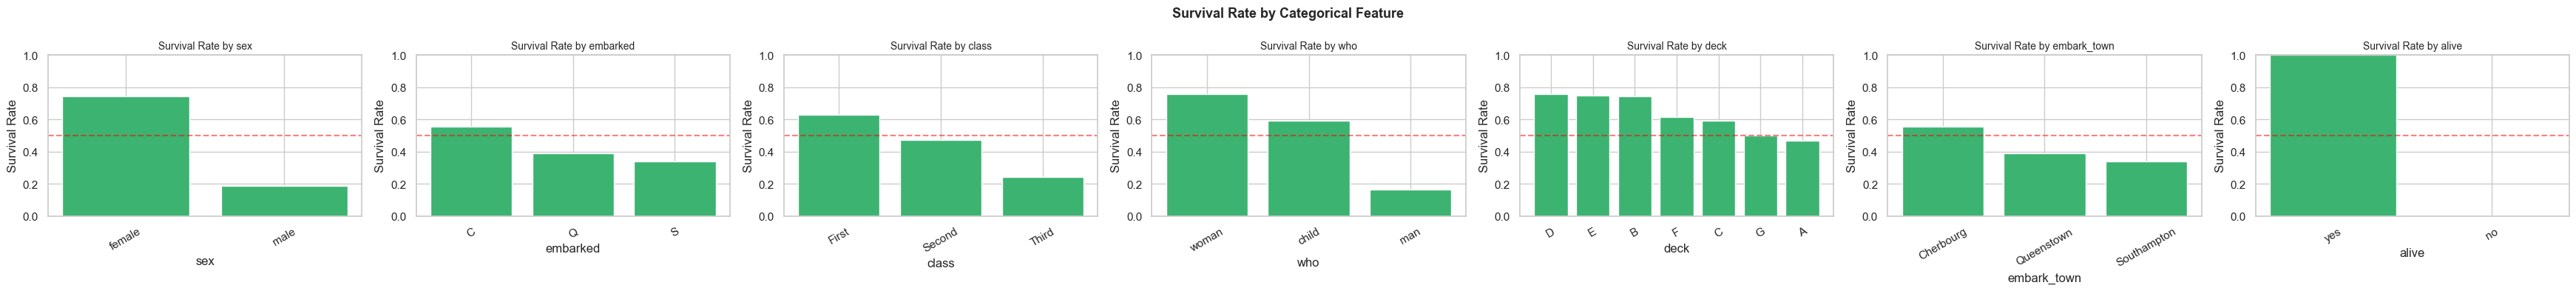

In [19]:
# ─── Survival Rate by Categorical Features ────────────────────────────────────
# This is the key business question: does any feature strongly correlate with the target?

if low_card_cats and target_col in df_raw.columns:
    fig, axes = plt.subplots(1, len(low_card_cats), figsize=(5 * len(low_card_cats), 4))
    if len(low_card_cats) == 1:
        axes = [axes]
    for i, col in enumerate(low_card_cats):
        survival_rate = df_raw.groupby(col)[target_col].mean().sort_values(ascending=False)
        axes[i].bar(survival_rate.index.astype(str), survival_rate.values,
                    color='mediumseagreen', edgecolor='white')
        axes[i].set_title(f'Survival Rate by {col}', fontsize=10)
        axes[i].set_ylim(0, 1)
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Survival Rate')
        axes[i].axhline(0.5, color='red', linestyle='--', alpha=0.5, label='50%')
        axes[i].tick_params(axis='x', rotation=30)
    plt.suptitle('Survival Rate by Categorical Feature', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

## Step 5 — Data Quality Assessment

In any real dataset, you will find:
- **Missing values** — cells with no data
- **Duplicates** — identical rows
- **Outliers** — extreme values that may be errors
- **Class imbalance** — one target class has far more rows than the other

Failing to handle these = silent model failures in production.

In [20]:
# ─── Missing Values Analysis ───────────────────────────────────────────────────
missing = df_raw.isnull().sum()
missing_pct = (df_raw.isnull().sum() / len(df_raw) * 100).round(2)

missing_report = pd.DataFrame({
    'missing_count' : missing,
    'missing_%'     : missing_pct,
    'dtype'         : df_raw.dtypes
}).sort_values('missing_%', ascending=False)

print('=== Missing Values Report ===')
print(missing_report[missing_report['missing_count'] > 0])

if missing_report['missing_count'].sum() == 0:
    print('No missing values found — this dataset is clean!')

=== Missing Values Report ===
             missing_count  missing_%     dtype
deck                   688      77.22  category
age                    177      19.87   float64
embarked                 2       0.22       str
embark_town              2       0.22       str


Missing value pattern (white = missing):


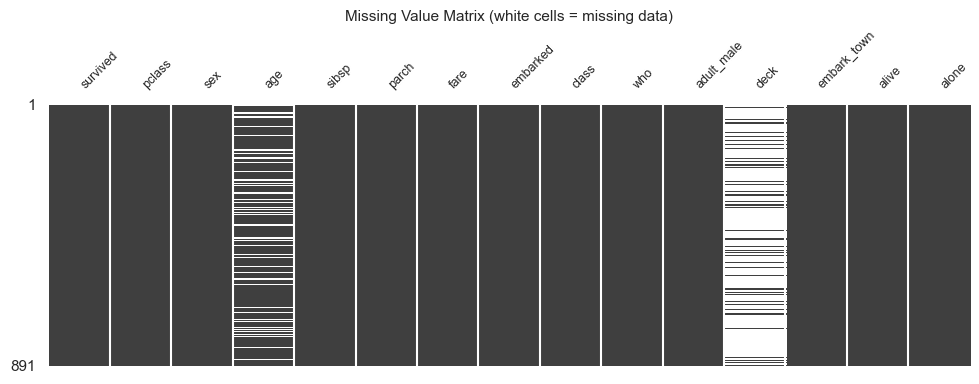

In [21]:
# ─── Visualise Missing Patterns ────────────────────────────────────────────────
# missingno shows WHERE data is missing — is it random, or in a pattern?
# A pattern (e.g. always missing together) tells you something about data collection

print('Missing value pattern (white = missing):')
fig, ax = plt.subplots(figsize=(10, 4))
msno.matrix(df_raw, ax=ax, fontsize=9, sparkline=False)
plt.title('Missing Value Matrix (white cells = missing data)', fontsize=11)
plt.tight_layout()
plt.show()

In [22]:
# ─── Duplicate Rows Check ──────────────────────────────────────────────────────
n_duplicates = df_raw.duplicated().sum()
print(f'Duplicate rows found: {n_duplicates}')

if n_duplicates > 0:
    print('First few duplicates:')
    print(df_raw[df_raw.duplicated(keep=False)].head())

Duplicate rows found: 107
First few duplicates:
    survived  pclass     sex   age  sibsp  parch    fare embarked  class  \
4          0       3    male  35.0      0      0  8.0500        S  Third   
26         0       3    male   NaN      0      0  7.2250        C  Third   
28         1       3  female   NaN      0      0  7.8792        Q  Third   
29         0       3    male   NaN      0      0  7.8958        S  Third   
32         1       3  female   NaN      0      0  7.7500        Q  Third   

      who  adult_male deck  embark_town alive  alone  
4     man        True  NaN  Southampton    no   True  
26    man        True  NaN    Cherbourg    no   True  
28  woman       False  NaN   Queenstown   yes   True  
29    man        True  NaN  Southampton    no   True  
32  woman       False  NaN   Queenstown   yes   True  


In [23]:
# ─── Outlier Detection (IQR Method) ───────────────────────────────────────────
# An outlier is a value so far from the rest that it may be a data error.
# IQR = Interquartile Range: Q3 - Q1
# Values beyond Q1 - 1.5*IQR or Q3 + 1.5*IQR are considered outliers.

print('=== Outlier Detection (IQR method) ===')
for col in numeric_cols:
    if col.lower() in ['passengerid', 'passenger_id', 'survived']:
        continue
    Q1 = df_raw[col].quantile(0.25)
    Q3 = df_raw[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_outliers = ((df_raw[col] < lower) | (df_raw[col] > upper)).sum()
    pct = n_outliers / len(df_raw) * 100
    if n_outliers > 0:
        print(f'  {col:12s}: {n_outliers:3d} outliers ({pct:.1f}%) | range: [{lower:.1f}, {upper:.1f}]')

=== Outlier Detection (IQR method) ===
  age         :  11 outliers (1.2%) | range: [-6.7, 64.8]
  sibsp       :  46 outliers (5.2%) | range: [-1.5, 2.5]
  parch       : 213 outliers (23.9%) | range: [0.0, 0.0]
  fare        : 116 outliers (13.0%) | range: [-26.7, 65.6]


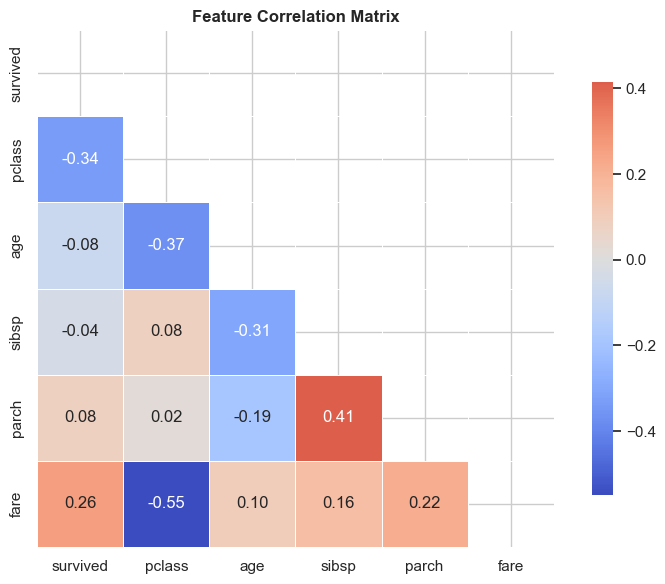

In [24]:
# ─── Correlation Matrix ────────────────────────────────────────────────────────
# Shows how strongly features relate to each other and to the target.
# Values close to +1 = strong positive correlation
# Values close to -1 = strong negative correlation  
# Values close to 0  = no linear relationship

corr_matrix = df_raw[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, mask=mask, ax=ax,
            linewidths=0.5, cbar_kws={'shrink': 0.8})
ax.set_title('Feature Correlation Matrix', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## Step 6 — Basic Data Cleaning

Based on the EDA findings, we apply targeted fixes:

| Issue | Strategy |
|---|---|
| Missing `age` (< 30%) | Fill with median age |
| Missing `embarked` (< 5%) | Fill with mode (most common port) |
| Missing `cabin` (> 70%) | Drop the column — too sparse to be useful |
| High-cardinality text columns | Drop `name`, `ticket` — not useful as raw text |
| ID column | Drop `passengerid` — not a feature |
| Duplicates | Drop duplicate rows |

In [25]:
# Work on a copy — never mutate the raw dataframe directly
df_clean = df_raw.copy()

# ── 1. Drop duplicate rows
before = len(df_clean)
df_clean = df_clean.drop_duplicates()
print(f'Duplicates removed: {before - len(df_clean)}')

# ── 2. Drop columns that are identifiers or too sparse
drop_cols = [c for c in df_clean.columns
             if c.lower() in ['passengerid', 'passenger_id', 'name', 'ticket', 'cabin']]
df_clean = df_clean.drop(columns=drop_cols, errors='ignore')
print(f'Dropped columns: {drop_cols}')

# ── 3. Impute missing numeric values with median
for col in df_clean.select_dtypes(include=np.number).columns:
    if df_clean[col].isnull().sum() > 0:
        median_val = df_clean[col].median()
        df_clean[col] = df_clean[col].fillna(median_val)
        print(f'Filled "{col}" missing values with median: {median_val:.2f}')

# ── 4. Impute missing categorical values with mode
for col in df_clean.select_dtypes(include='object').columns:
    if df_clean[col].isnull().sum() > 0:
        mode_val = df_clean[col].mode()[0]
        df_clean[col] = df_clean[col].fillna(mode_val)
        print(f'Filled "{col}" missing values with mode: "{mode_val}"')

# ── 5. Verify no nulls remain
remaining_nulls = df_clean.isnull().sum().sum()
print(f'\nRemaining null values after cleaning: {remaining_nulls}')
print(f'Shape after cleaning: {df_clean.shape}')

Duplicates removed: 107
Dropped columns: []
Filled "age" missing values with median: 28.25
Filled "embarked" missing values with mode: "S"
Filled "embark_town" missing values with mode: "Southampton"

Remaining null values after cleaning: 582
Shape after cleaning: (784, 15)


In [26]:
# Preview cleaned data
print('=== Cleaned DataFrame sample ===')
df_clean.head(10)

=== Cleaned DataFrame sample ===


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.00,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.00,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.00,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.00,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.00,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
5,0,3,male,28.25,0,0,8.4583,Q,Third,man,True,NaN,Queenstown,no,True
6,0,1,male,54.00,0,0,51.8625,S,First,man,True,E,Southampton,no,True
7,0,3,male,2.00,3,1,21.0750,S,Third,child,False,NaN,Southampton,no,False
8,1,3,female,27.00,0,2,11.1333,S,Third,woman,False,NaN,Southampton,yes,False
9,1,2,female,14.00,1,0,30.0708,C,Second,child,False,NaN,Cherbourg,yes,False


## Step 7 — Data Validation

Before saving or passing data to a training pipeline, you **must validate** that it meets expected rules.  
This is the "Great Expectations" concept in code — but written manually first so you understand it.

In production, a validation failure should **stop the pipeline** and raise an alert rather than silently pass bad data downstream.

In [27]:
def validate_dataset(df: pd.DataFrame) -> dict:
    """
    Run data quality validation checks.
    Returns a dict of {check_name: (passed: bool, detail: str)}.
    In production, a FAILED check would trigger an alert and halt the pipeline.
    """
    results = {}
    
    # Check 1: No null values remain
    null_count = df.isnull().sum().sum()
    results['no_nulls'] = (
        null_count == 0,
        f'{null_count} null values found'
    )
    
    # Check 2: Minimum number of rows
    min_rows = 100
    results['min_row_count'] = (
        len(df) >= min_rows,
        f'{len(df)} rows (minimum: {min_rows})'
    )
    
    # Check 3: Target column exists and is binary
    target = 'survived'
    if target in df.columns:
        unique_values = set(df[target].unique())
        results['target_is_binary'] = (
            unique_values.issubset({0, 1}),
            f'Unique target values: {sorted(unique_values)}'
        )
    
    # Check 4: No duplicate rows
    duplicates = df.duplicated().sum()
    results['no_duplicates'] = (
        duplicates == 0,
        f'{duplicates} duplicate rows found'
    )
    
    # Check 5: Class imbalance (warn if one class is < 20% of total)
    if target in df.columns:
        minority_pct = df[target].value_counts(normalize=True).min() * 100
        results['class_balance_warning'] = (
            minority_pct >= 20,
            f'Minority class is {minority_pct:.1f}% of data (threshold: 20%)'
        )
    
    # Check 6: Numeric columns have sensible ranges
    if 'pclass' in df.columns:
        results['pclass_range'] = (
            df['pclass'].between(1, 3).all(),
            f'pclass values: {sorted(df["pclass"].unique())} (expected 1, 2, or 3)'
        )
    
    if 'age' in df.columns:
        results['age_range'] = (
            df['age'].between(0, 120).all(),
            f'age range: [{df["age"].min():.0f}, {df["age"].max():.0f}]'
        )
    
    return results


# Run validation
validation_results = validate_dataset(df_clean)

print('=== Data Validation Report ===')
all_passed = True
for check, (passed, detail) in validation_results.items():
    status = '✅ PASS' if passed else '❌ FAIL'
    print(f'{status}  {check:30s} | {detail}')
    if not passed:
        all_passed = False

print(f'\nOverall: {"ALL CHECKS PASSED" if all_passed else "SOME CHECKS FAILED — review before proceeding"}')

=== Data Validation Report ===
❌ FAIL  no_nulls                       | 582 null values found
✅ PASS  min_row_count                  | 784 rows (minimum: 100)
✅ PASS  target_is_binary               | Unique target values: [np.int64(0), np.int64(1)]
✅ PASS  no_duplicates                  | 0 duplicate rows found
✅ PASS  class_balance_warning          | Minority class is 41.2% of data (threshold: 20%)
✅ PASS  pclass_range                   | pclass values: [np.int64(1), np.int64(2), np.int64(3)] (expected 1, 2, or 3)
✅ PASS  age_range                      | age range: [0, 80]

Overall: SOME CHECKS FAILED — review before proceeding


## Step 8 — Export to Disk

After ingestion and cleaning, save the data in two formats:

| Format | When to use |
|---|---|
| **CSV** | Human-readable, easy to share, slower for large data |
| **Parquet** | Columnar binary format — much faster to read, smaller file size. Industry standard for data pipelines. |

In a real pipeline, this saved file would be the **input to the next stage** (feature engineering).

In [28]:
# Create output directory
output_dir = '../data'
raw_dir = os.path.join(output_dir, 'raw')
processed_dir = os.path.join(output_dir, 'processed')

os.makedirs(raw_dir, exist_ok=True)
os.makedirs(processed_dir, exist_ok=True)

# Save raw data (snapshot of what was downloaded — never throw away raw data)
raw_csv_path = os.path.join(raw_dir, 'titanic_raw.csv')
df_raw.to_csv(raw_csv_path, index=False)
print(f'Raw data saved to:       {raw_csv_path}')

# Save cleaned data as CSV
clean_csv_path = os.path.join(processed_dir, 'titanic_clean.csv')
df_clean.to_csv(clean_csv_path, index=False)
print(f'Cleaned CSV saved to:    {clean_csv_path}')

# Save cleaned data as Parquet (preferred for pipelines)
clean_parquet_path = os.path.join(processed_dir, 'titanic_clean.parquet')
df_clean.to_parquet(clean_parquet_path, index=False, engine='pyarrow')
print(f'Cleaned Parquet saved to: {clean_parquet_path}')

# Compare file sizes
csv_size = os.path.getsize(clean_csv_path) / 1024
parquet_size = os.path.getsize(clean_parquet_path) / 1024
print(f'\nFile size comparison:')
print(f'  CSV:     {csv_size:.1f} KB')
print(f'  Parquet: {parquet_size:.1f} KB  ({(1 - parquet_size/csv_size)*100:.0f}% smaller)')

Raw data saved to:       ../data/raw/titanic_raw.csv
Cleaned CSV saved to:    ../data/processed/titanic_clean.csv
Cleaned Parquet saved to: ../data/processed/titanic_clean.parquet

File size comparison:
  CSV:     49.9 KB
  Parquet: 13.9 KB  (72% smaller)


In [29]:
# Verify the saved Parquet file loads back correctly
df_verify = pd.read_parquet(clean_parquet_path)

print('=== Verification: Parquet file reloaded successfully ===')
print(f'Shape: {df_verify.shape}')
print(f'Columns: {list(df_verify.columns)}')
df_verify.head(3)

=== Verification: Parquet file reloaded successfully ===
Shape: (784, 15)
Columns: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True


## Summary — What We Did

| Step | What happened | Key insight |
|---|---|---|
| **Load** | Loaded `titanic` via `seaborn.load_dataset()` | In production: read from DB/S3/API |
| **Structure** | Inspected columns, types, shape | Always do this before anything else |
| **EDA** | Plotted distributions, survival rates, correlations | Visuals reveal what numbers hide |
| **Quality check** | Found nulls, outliers, class imbalance | Problems here → broken models later |
| **Cleaning** | Imputed nulls, dropped useless columns | Keep raw copy — never overwrite |
| **Validation** | Automated rules that fail loudly | In production: stops the pipeline |
| **Export** | CSV + Parquet to `data/processed/` | Parquet is smaller and faster to read |

---

## What Comes Next

The cleaned Parquet file `titanic_clean.parquet` is now the **input to Stage 2: Feature Engineering**.  
In the next notebook, we will:
- Encode categorical columns (`sex`, `embarked`) into numbers
- Scale numeric features
- Create new features (e.g. `family_size = sibsp + parch`)
- Build a scikit-learn `Pipeline` to prevent training-serving leakage

---

**Connection to your existing tutorial:**  
Your `credit-approval-training-data.csv` is essentially a pre-ingested dataset — someone already did Steps 1–8 before giving it to you.  
In any real job you will need to do these steps yourself, often with messy, incomplete data.
